Importing the Dependencies

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

Data Collection & Analysis

In [3]:
# loading the data from csv file to a pandas dataframe
customer_data = pd.read_csv('/content/Mall_Customers.csv')

In [4]:
# number of rows and columns
customer_data.shape

(200, 5)

In [5]:
# info about the data/columns
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# statistical measures for each column
customer_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
# first 5 rows in the data
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
customer_data.drop('CustomerID', axis=1, inplace=True)

Choosing the Annual Income Column & Spending Score Column

In [18]:
X = customer_data.iloc[:,-2:]

In [19]:
customer_data.Gender = customer_data.Gender.astype('category').cat.codes

In [28]:
inertia= []
for i in range(2,10,1):
  kmeans = KMeans(n_clusters=i)
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)
  print(f'The inertia for {i} clusters is {kmeans.inertia_}')

The inertia for 2 clusters is 184102.1534926472
The inertia for 3 clusters is 106348.37306211119
The inertia for 4 clusters is 73880.64496247198
The inertia for 5 clusters is 44448.45544793369
The inertia for 6 clusters is 37271.88623658948
The inertia for 7 clusters is 31609.77704998489
The inertia for 8 clusters is 28067.275533403794
The inertia for 9 clusters is 22851.508369408373


Text(0.5, 0, 'Number of Clusters')

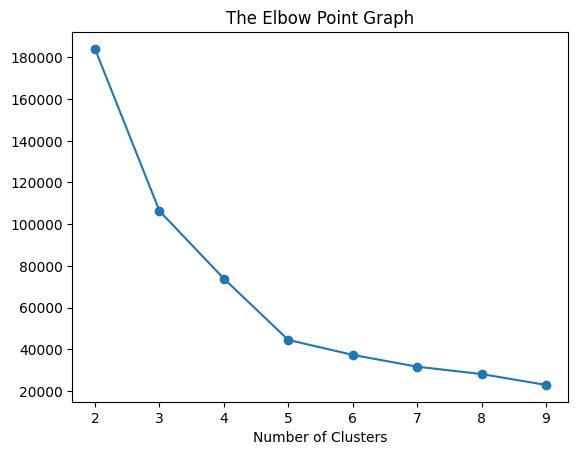

In [37]:
plt.plot(range(2,10,1), inertia, marker='o')
plt.xticks(range(2,10,1))
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')

Optimum Number of Clusters = 5

Training the K-Means Clustering Model

In [39]:
kmeans = KMeans(n_clusters=5, random_state=1)
Y = kmeans.fit_predict(X)

Visualizing all the Clusters

In [42]:
X.iloc[:,0]

,Annual Income (k$)
0,15
1,15
2,16
3,16
4,17
...,...
195,120
196,126
197,126
198,137


In [55]:
cluster_centers = kmeans.cluster_centers_

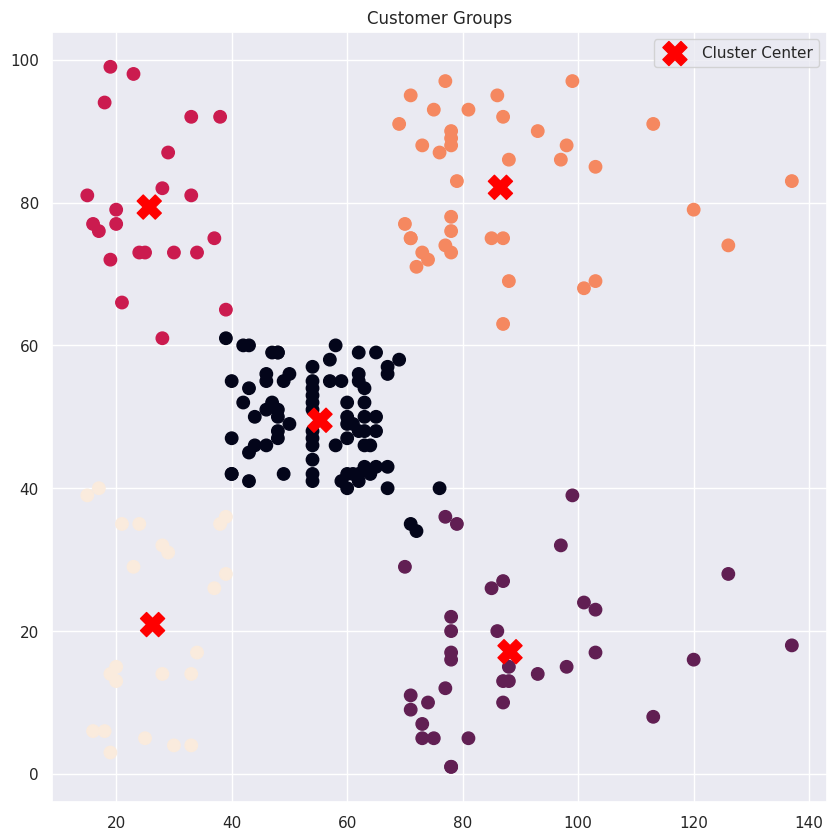

In [93]:
sns.set()
plt.figure(figsize=(10,10))
plt.scatter(X.iloc[:,0],X.iloc[:,1], c=Y, s=80)
plt.scatter(cluster_centers[:,0], cluster_centers[:,1],marker='X', s=300,c='red', linestyle='', label='Cluster Center')
plt.title('Customer Groups')
plt.legend()